# cn_full_v3qc_v2 composition — k-mer distributions by founder side

**Created 2026-05-18.** Visualizes the k-mer carrier matrix `cn_full_231_v3qc_v2/cn_Chr1.cn.npz` to make the cactus-vs-PG asymmetry concrete.

Plots:
1. **K_f**: total k-mers per founder (row sum) — distribution per side
2. **Private k-mers per founder** (ac=1 columns only) — distribution per side
3. **ac_k**: k-mer multiplicity across founders — overall + per-side breakdown
4. **K_f vs private k-mers per founder** (scatter, colored by side)
5. **Cactus-only-shared / PG-only-shared / mixed** column counts
6. **Shared k-mers per founder** (ac≥2 only)

In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.sparse import load_npz

ROOT = Path('/global/scratch/users/tbellg/hapfire_sv')
CN_PATH   = ROOT / 'poolfreq/data/cn_full_231_v3qc_v2/cn_Chr1.cn.npz'
META_PATH = ROOT / 'poolfreq/data/cn_full_231_v3qc_v2/cn_Chr1.meta.npz'
# Founders come from cn_full meta directly (cn_var rebuild in progress)
SPLIT     = ROOT / 'data/founder_split_cactus_pg.json'

cn = load_npz(CN_PATH).tocsr()
F, K = cn.shape
print(f'cn_full Chr1: shape=({F}, {K:,}) nnz={cn.nnz:,}  density={cn.nnz/(F*K)*100:.3f}%')

# Founder order — pull from cn_var meta (same order as cn_full)
cnfm = np.load(META_PATH, allow_pickle=True)
founders = np.asarray(cnfm['founders']).astype(str)
assert len(founders) == F, f'founder count mismatch: meta={len(founders)}, cn_full={F}'

with open(SPLIT) as f:
    split = json.load(f)
cactus_set = set(map(str, split['cactus']))
pg_set = set(map(str, split['PG']))
is_cactus = np.array([f in cactus_set for f in founders])
is_pg = np.array([f in pg_set for f in founders])
n_cactus = int(is_cactus.sum())
n_pg = int(is_pg.sum())
print(f'cactus founders: {n_cactus}, PG founders: {n_pg}, unlabeled: {F - n_cactus - n_pg}')

cn_full Chr1: shape=(231, 22,673,541) nnz=399,055,958  density=7.619%
cactus founders: 80, PG founders: 151, unlabeled: 0


In [2]:
# Per-founder K_f (row sum)
Kf = np.asarray(cn.sum(axis=1)).flatten()

# Per-kmer ac_k (col sum) — number of founders carrying each k-mer
cnT = cn.T.tocsr()
ac = np.asarray(cn.sum(axis=0)).flatten()

# Per-side cactus/PG kmer participation (founders × kmers → side × kmers)
# n_cactus_carriers_per_kmer: how many cactus founders carry each k-mer
ac_cactus = np.asarray(cn[is_cactus, :].sum(axis=0)).flatten()
ac_pg     = np.asarray(cn[is_pg, :].sum(axis=0)).flatten()
assert np.all(ac == ac_cactus + ac_pg), 'ac decomposition mismatch'

# Private k-mers per founder: k-mers carried by EXACTLY 1 founder. For founder f,
# count of columns where ac=1 AND cn[f, that col] = 1.
ac1_mask = (ac == 1)
n_kmers_total = K
n_priv_kmers = int(ac1_mask.sum())
print(f'Total k-mers (Chr1): {K:,}')
print(f'  ac=0 (no carrier):              {(ac==0).sum():,} ({(ac==0).sum()/K*100:.2f}%)')
print(f'  ac=1 (private k-mers):          {n_priv_kmers:,} ({n_priv_kmers/K*100:.2f}%)')
print(f'  ac=2 (doubletons):              {(ac==2).sum():,}')
print(f'  ac∈[3,10]:                       {((ac>=3)&(ac<=10)).sum():,}')
print(f'  ac>10:                          {(ac>10).sum():,}')

# Per-founder private k-mer count
priv_per_founder = np.asarray(cn[:, ac1_mask].sum(axis=1)).flatten()

print(f'\nPer-founder K_f: median={np.median(Kf):,.0f}, mean={Kf.mean():,.0f}, '
      f'min={Kf.min():,.0f}, max={Kf.max():,.0f}')
print(f'  cactus median K_f: {np.median(Kf[is_cactus]):,.0f}')
print(f'  PG median K_f:     {np.median(Kf[is_pg]):,.0f}')
print(f'  ratio cactus/PG:   {np.median(Kf[is_cactus])/np.median(Kf[is_pg]):.3f}')

print(f'\nPer-founder private k-mers (ac=1): median={np.median(priv_per_founder):,.0f}')
print(f'  cactus median private: {np.median(priv_per_founder[is_cactus]):,.0f}')
print(f'  PG median private:     {np.median(priv_per_founder[is_pg]):,.0f}')
print(f'  ratio cactus/PG:       {np.median(priv_per_founder[is_cactus])/np.median(priv_per_founder[is_pg]):.3f}')

Total k-mers (Chr1): 22,673,541
  ac=0 (no carrier):              5,655,313 (24.94%)
  ac=1 (private k-mers):          7,461,147 (32.91%)
  ac=2 (doubletons):              2,159,516
  ac∈[3,10]:                       3,922,110


  ac>10:                          3,475,455



Per-founder K_f: median=1,438,897, mean=1,727,515, min=1,292,560, max=2,499,619
  cactus median K_f: 2,303,590
  PG median K_f:     1,431,243
  ratio cactus/PG:   1.610

Per-founder private k-mers (ac=1): median=2,598
  cactus median private: 54,345
  PG median private:     1,401
  ratio cactus/PG:       38.790


## Plot 1: K_f distribution — total k-mers per founder, by side

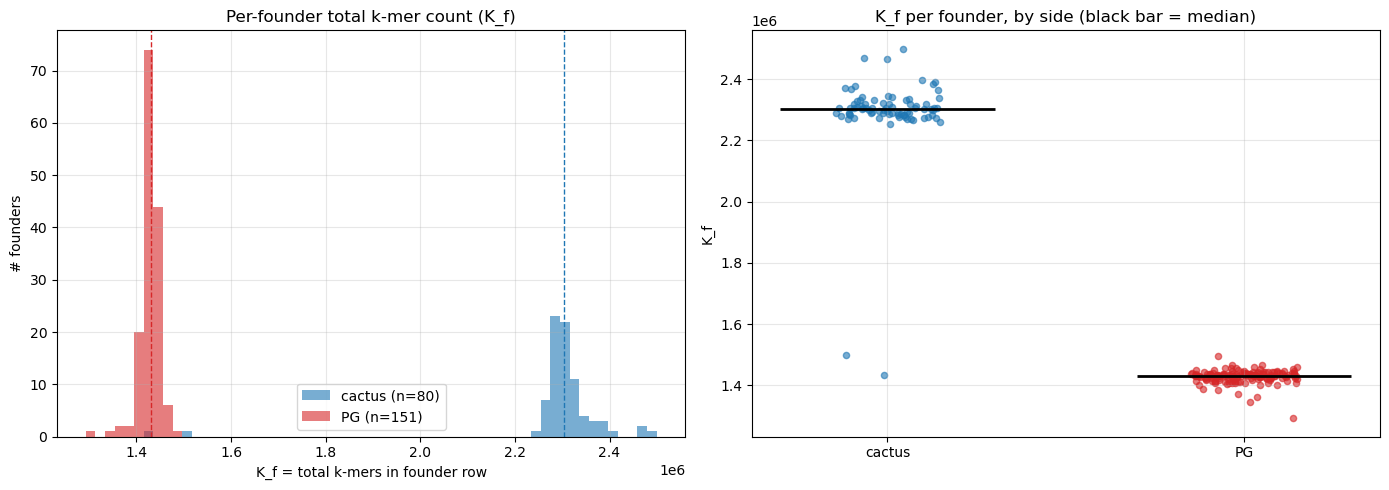

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
bins = np.linspace(Kf.min(), Kf.max(), 60)
ax.hist(Kf[is_cactus], bins=bins, alpha=0.6, color='#1f77b4', label=f'cactus (n={n_cactus})')
ax.hist(Kf[is_pg],     bins=bins, alpha=0.6, color='#d62728', label=f'PG (n={n_pg})')
ax.axvline(np.median(Kf[is_cactus]), color='#1f77b4', ls='--', lw=1)
ax.axvline(np.median(Kf[is_pg]),     color='#d62728', ls='--', lw=1)
ax.set_xlabel('K_f = total k-mers in founder row')
ax.set_ylabel('# founders')
ax.set_title('Per-founder total k-mer count (K_f)')
ax.legend()
ax.grid(alpha=0.3)

# Strip plot (per-founder)
ax = axes[1]
jitter_c = np.random.uniform(-0.15, 0.15, n_cactus)
jitter_p = np.random.uniform(-0.15, 0.15, n_pg)
ax.scatter(jitter_c + 0,   Kf[is_cactus], color='#1f77b4', alpha=0.6, s=20, label=f'cactus')
ax.scatter(jitter_p + 1,   Kf[is_pg],     color='#d62728', alpha=0.6, s=20, label=f'PG')
for x, vals in [(0, Kf[is_cactus]), (1, Kf[is_pg])]:
    ax.hlines(np.median(vals), x-0.3, x+0.3, colors='k', lw=2)
ax.set_xticks([0, 1]); ax.set_xticklabels(['cactus', 'PG'])
ax.set_ylabel('K_f')
ax.set_title('K_f per founder, by side (black bar = median)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/CN_FULL_COMPOSITION_kf.png', dpi=130, bbox_inches='tight')
plt.show()

## Plot 2: Private k-mer count per founder, by side

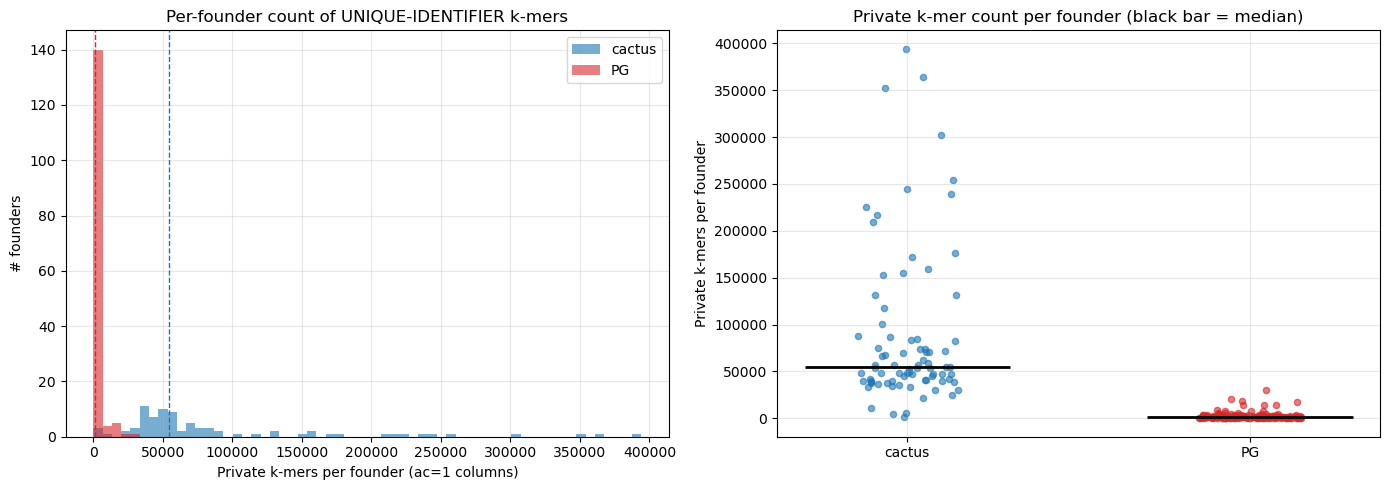

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bins = np.linspace(priv_per_founder.min(), priv_per_founder.max(), 60)
ax.hist(priv_per_founder[is_cactus], bins=bins, alpha=0.6, color='#1f77b4', label=f'cactus')
ax.hist(priv_per_founder[is_pg],     bins=bins, alpha=0.6, color='#d62728', label=f'PG')
ax.axvline(np.median(priv_per_founder[is_cactus]), color='#1f77b4', ls='--', lw=1)
ax.axvline(np.median(priv_per_founder[is_pg]),     color='#d62728', ls='--', lw=1)
ax.set_xlabel('Private k-mers per founder (ac=1 columns)')
ax.set_ylabel('# founders')
ax.set_title('Per-founder count of UNIQUE-IDENTIFIER k-mers')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.scatter(jitter_c + 0,  priv_per_founder[is_cactus], color='#1f77b4', alpha=0.6, s=20)
ax.scatter(jitter_p + 1,  priv_per_founder[is_pg],     color='#d62728', alpha=0.6, s=20)
for x, vals in [(0, priv_per_founder[is_cactus]), (1, priv_per_founder[is_pg])]:
    ax.hlines(np.median(vals), x-0.3, x+0.3, colors='k', lw=2)
ax.set_xticks([0, 1]); ax.set_xticklabels(['cactus', 'PG'])
ax.set_ylabel('Private k-mers per founder')
ax.set_title('Private k-mer count per founder (black bar = median)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/CN_FULL_COMPOSITION_private.png', dpi=130, bbox_inches='tight')
plt.show()

## Plot 3: ac_k distribution — k-mer multiplicity across all founders

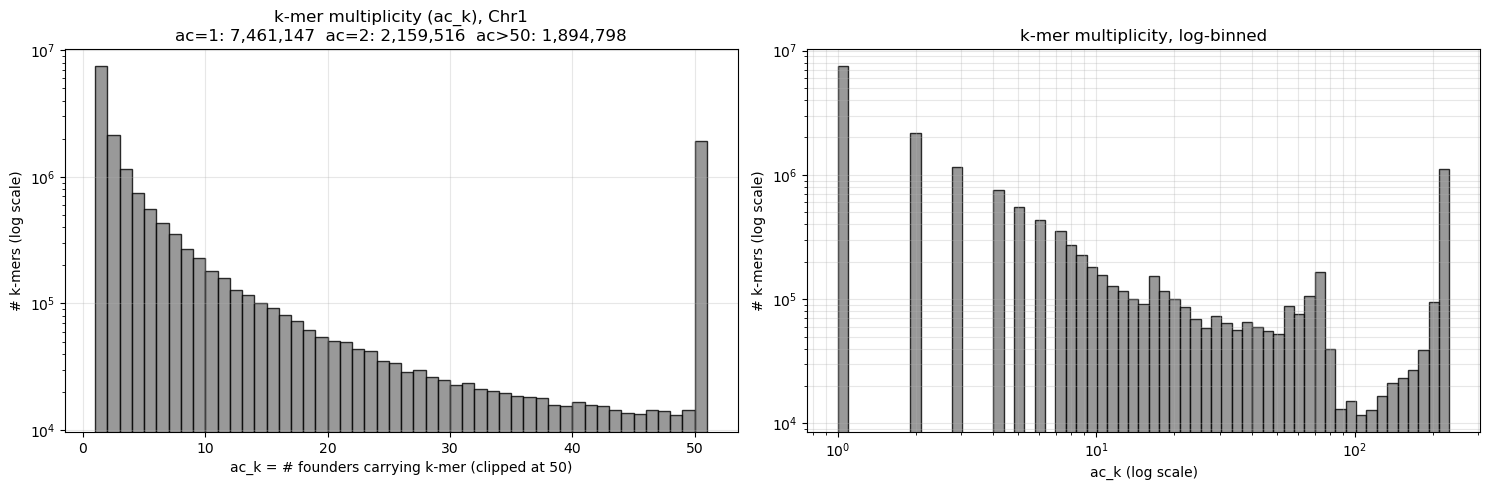

In [5]:
# Truncated histogram: keep ac in [1, 50] for readability; tail bucket for ac>50
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Linear bins
ax = axes[0]
ac_clip = np.minimum(ac, 50)
ax.hist(ac_clip[ac > 0], bins=np.arange(1, 52), color='gray', edgecolor='k', alpha=0.8)
ax.set_yscale('log')
ax.set_xlabel('ac_k = # founders carrying k-mer (clipped at 50)')
ax.set_ylabel('# k-mers (log scale)')
ax.set_title(f'k-mer multiplicity (ac_k), Chr1\nac=1: {(ac==1).sum():,}  ac=2: {(ac==2).sum():,}  ac>50: {(ac>50).sum():,}')
ax.grid(alpha=0.3)

# Log-bin: shows the full tail structure
ax = axes[1]
log_bins = np.logspace(0, np.log10(F + 1), 60)
ax.hist(ac[ac > 0], bins=log_bins, color='gray', edgecolor='k', alpha=0.8)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('ac_k (log scale)')
ax.set_ylabel('# k-mers (log scale)')
ax.set_title('k-mer multiplicity, log-binned')
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('plots/CN_FULL_COMPOSITION_ac.png', dpi=130, bbox_inches='tight')
plt.show()

## Plot 4: Cactus-only-shared / PG-only-shared / mixed k-mer breakdown

For each k-mer with ac≥2, classify by carrier composition:
- **all-cactus**: carriers ⊂ cactus founders
- **all-PG**: carriers ⊂ PG founders
- **mixed**: at least one carrier from each side

Shared k-mers (ac>=2) on Chr1: 9,557,081
  all-cactus (no PG carriers):   4,723,775 (49.4%)
  all-PG (no cactus carriers):   252,196     (2.6%)
  mixed (both sides):            4,581,110     (47.9%)


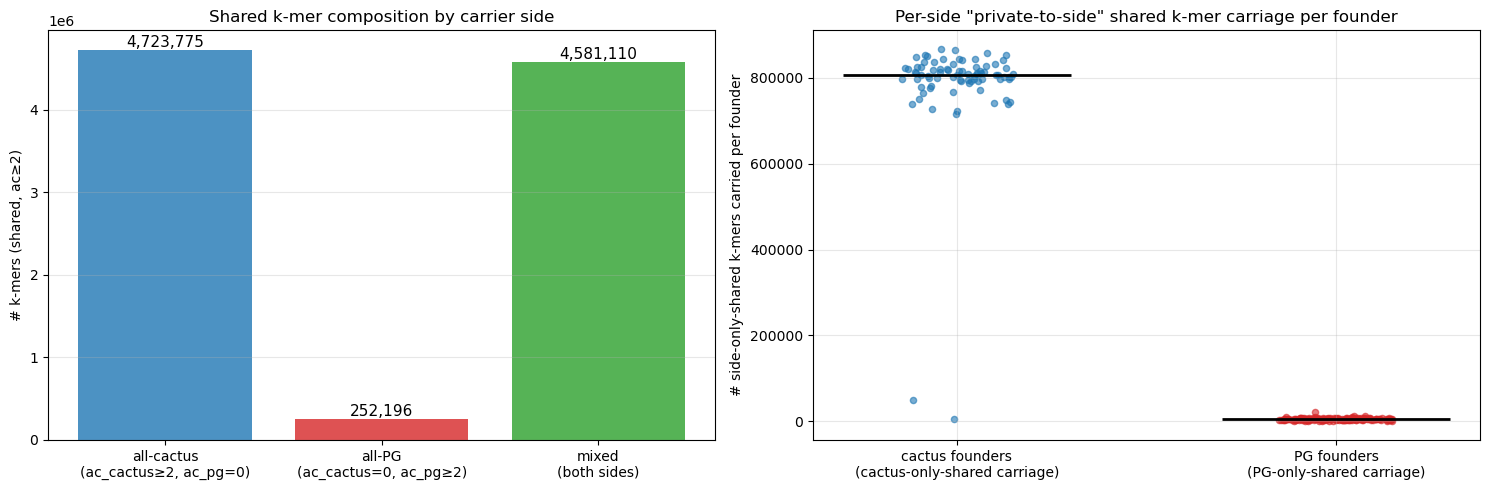


Per-founder side-only-shared k-mer carriage:
  cactus median (cactus-only-shared per cactus founder): 806,894
  PG     median (PG-only-shared per PG founder):         5,061
  ratio: 159.43


In [6]:
ac_shared_mask = ac >= 2
n_shared = int(ac_shared_mask.sum())

all_cactus = ac_shared_mask & (ac_pg == 0) & (ac_cactus >= 2)
all_pg     = ac_shared_mask & (ac_cactus == 0) & (ac_pg >= 2)
mixed      = ac_shared_mask & (ac_cactus >= 1) & (ac_pg >= 1)

# Sanity: should partition the shared set
assert all_cactus.sum() + all_pg.sum() + mixed.sum() == n_shared, 'partition mismatch'

print(f'Shared k-mers (ac>=2) on Chr1: {n_shared:,}')
print(f'  all-cactus (no PG carriers):   {all_cactus.sum():,} ({all_cactus.sum()/n_shared*100:.1f}%)')
print(f'  all-PG (no cactus carriers):   {all_pg.sum():,}     ({all_pg.sum()/n_shared*100:.1f}%)')
print(f'  mixed (both sides):            {mixed.sum():,}     ({mixed.sum()/n_shared*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart of counts
ax = axes[0]
categories = ['all-cactus\n(ac_cactus≥2, ac_pg=0)',
              'all-PG\n(ac_cactus=0, ac_pg≥2)',
              'mixed\n(both sides)']
counts = [int(all_cactus.sum()), int(all_pg.sum()), int(mixed.sum())]
colors = ['#1f77b4', '#d62728', '#2ca02c']
bars = ax.bar(categories, counts, color=colors, alpha=0.8)
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f'{c:,}',
            ha='center', va='bottom', fontsize=11)
ax.set_ylabel('# k-mers (shared, ac≥2)')
ax.set_title('Shared k-mer composition by carrier side')
ax.grid(alpha=0.3, axis='y')

# Per-founder breakdown: how many cactus-only-shared k-mers does each cactus founder carry?
# (Compare to all-PG-shared per PG founder)
ax = axes[1]
cactus_only_per_founder = np.asarray(cn[:, all_cactus].sum(axis=1)).flatten()
pg_only_per_founder     = np.asarray(cn[:, all_pg].sum(axis=1)).flatten()
mixed_per_founder       = np.asarray(cn[:, mixed].sum(axis=1)).flatten()

ax.scatter(jitter_c + 0, cactus_only_per_founder[is_cactus], color='#1f77b4', alpha=0.6, s=20)
ax.scatter(jitter_p + 1, pg_only_per_founder[is_pg],         color='#d62728', alpha=0.6, s=20)
for x, vals in [(0, cactus_only_per_founder[is_cactus]),
                (1, pg_only_per_founder[is_pg])]:
    ax.hlines(np.median(vals), x-0.3, x+0.3, colors='k', lw=2)
ax.set_xticks([0, 1]); ax.set_xticklabels(['cactus founders\n(cactus-only-shared carriage)',
                                            'PG founders\n(PG-only-shared carriage)'])
ax.set_ylabel('# side-only-shared k-mers carried per founder')
ax.set_title('Per-side "private-to-side" shared k-mer carriage per founder')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/CN_FULL_COMPOSITION_side_shared.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'\nPer-founder side-only-shared k-mer carriage:')
print(f'  cactus median (cactus-only-shared per cactus founder): {np.median(cactus_only_per_founder[is_cactus]):,.0f}')
print(f'  PG     median (PG-only-shared per PG founder):         {np.median(pg_only_per_founder[is_pg]):,.0f}')
print(f'  ratio: {np.median(cactus_only_per_founder[is_cactus]) / np.median(pg_only_per_founder[is_pg]):.2f}')

## Plot 5: K_f vs private k-mer count (scatter, colored by side)

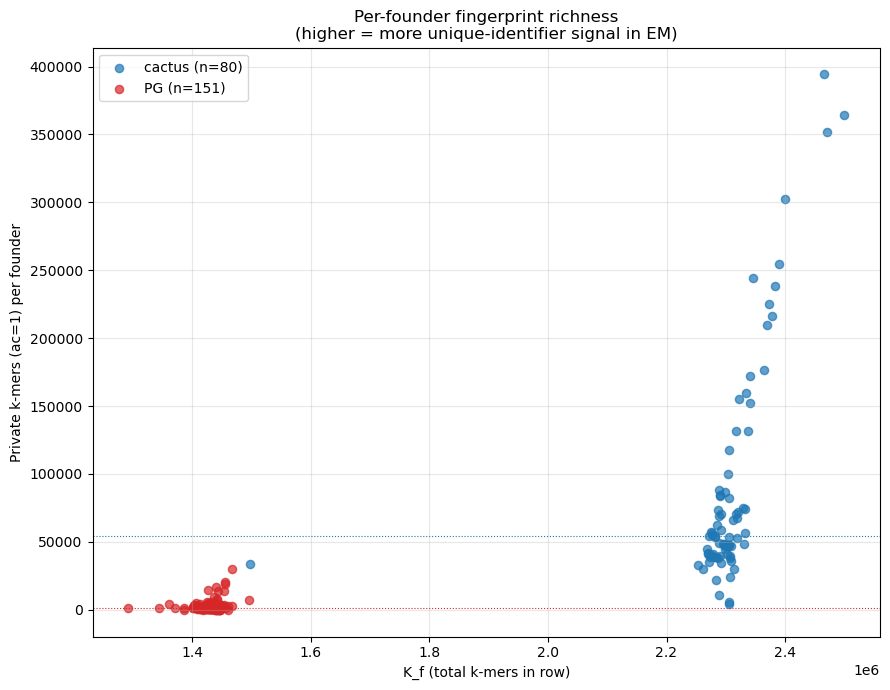

In [7]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(Kf[is_cactus], priv_per_founder[is_cactus], color='#1f77b4', alpha=0.7, s=35, label=f'cactus (n={n_cactus})')
ax.scatter(Kf[is_pg],     priv_per_founder[is_pg],     color='#d62728', alpha=0.7, s=35, label=f'PG (n={n_pg})')
ax.axhline(np.median(priv_per_founder[is_cactus]), color='#1f77b4', ls=':', lw=0.8)
ax.axhline(np.median(priv_per_founder[is_pg]),     color='#d62728', ls=':', lw=0.8)
ax.set_xlabel('K_f (total k-mers in row)')
ax.set_ylabel('Private k-mers (ac=1) per founder')
ax.set_title('Per-founder fingerprint richness\n(higher = more unique-identifier signal in EM)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/CN_FULL_COMPOSITION_kf_vs_priv.png', dpi=130, bbox_inches='tight')
plt.show()

## Summary table

In [8]:
import pandas as pd
summary = pd.DataFrame({
    'metric': [
        'n founders',
        'K_f median (total k-mers per founder)',
        'K_f mean',
        'private k-mers per founder (median)',
        'cactus-only-shared k-mers per founder (median)',
        'PG-only-shared k-mers per founder (median)',
        'mixed-shared k-mers per founder (median)',
    ],
    'cactus': [
        n_cactus,
        f'{np.median(Kf[is_cactus]):,.0f}',
        f'{Kf[is_cactus].mean():,.0f}',
        f'{np.median(priv_per_founder[is_cactus]):,.0f}',
        f'{np.median(cactus_only_per_founder[is_cactus]):,.0f}',
        f'{np.median(pg_only_per_founder[is_cactus]):,.0f} (carriage = 0 by construction)',
        f'{np.median(mixed_per_founder[is_cactus]):,.0f}',
    ],
    'PG': [
        n_pg,
        f'{np.median(Kf[is_pg]):,.0f}',
        f'{Kf[is_pg].mean():,.0f}',
        f'{np.median(priv_per_founder[is_pg]):,.0f}',
        f'{np.median(cactus_only_per_founder[is_pg]):,.0f} (carriage = 0 by construction)',
        f'{np.median(pg_only_per_founder[is_pg]):,.0f}',
        f'{np.median(mixed_per_founder[is_pg]):,.0f}',
    ],
})
print(summary.to_string(index=False))

                                        metric                           cactus                               PG
                                    n founders                               80                              151
         K_f median (total k-mers per founder)                        2,303,590                        1,431,243
                                      K_f mean                        2,291,939                        1,428,482
           private k-mers per founder (median)                           54,345                            1,401
cactus-only-shared k-mers per founder (median)                          806,894 0 (carriage = 0 by construction)
    PG-only-shared k-mers per founder (median) 0 (carriage = 0 by construction)                            5,061
      mixed-shared k-mers per founder (median)                        1,421,352                        1,422,764


# Effect of "mixed-only" subsetting on cn_full composition

How does restricting cn_full to k-mers carried by BOTH cactus AND PG sides change the per-founder distribution? Three tiers compared:

- **mixed-loose**: `ac_cactus ≥ 1 AND ac_pg ≥ 1` — every k-mer has at least 1 cactus AND 1 PG carrier. Drops cactus-only and PG-only shared k-mers + all private k-mers.
- **mixed-strict**: `ac_cactus ≥ 5 AND ac_pg ≥ 5` — k-mers carried by ≥5 founders per side.
- **mixed-conserv**: `ac_cactus ≥ 10 AND ac_pg ≥ 10` — k-mers carried by ≥10 founders per side.

The "mixed-only" filter is conceptually parallel to what hapFIRE does (uses SNP data which is reliably called on both panels). It rebalances at the data level — no post-hoc correction needed.

In [9]:
# Define the three mixed-only masks on the existing ac/ac_cactus/ac_pg arrays
mask_full       = np.ones(K, dtype=bool)
mask_loose      = (ac_cactus >= 1) & (ac_pg >= 1)
mask_strict     = (ac_cactus >= 5) & (ac_pg >= 5)
mask_conserv    = (ac_cactus >= 10) & (ac_pg >= 10)

TIER_LABELS = ['full', 'mixed-loose', 'mixed-strict', 'mixed-conserv']
TIER_MASKS  = [mask_full, mask_loose, mask_strict, mask_conserv]
TIER_COLORS = ['#444444', '#2ca02c', '#1f77b4', '#9467bd']

# Compute per-founder K_f and per-founder private k-mers for each tier
tier_stats = {}
for label, m in zip(TIER_LABELS, TIER_MASKS):
    sub = cn[:, m]
    Kf_t = np.asarray(sub.sum(axis=1)).flatten()
    ac_t = np.asarray(sub.sum(axis=0)).flatten()
    # private-within-tier: ac==1 columns
    priv_mask = (ac_t == 1)
    priv_t = np.asarray(sub[:, priv_mask].sum(axis=1)).flatten() if priv_mask.sum() else np.zeros(F)
    tier_stats[label] = {
        'n_kmers': int(m.sum()),
        'Kf': Kf_t,
        'priv_per_founder': priv_t,
        'mask': m,
    }
    print(f'  {label:>16s}: n_kmers={m.sum():>12,}  '
          f'K_f cactus med={int(np.median(Kf_t[is_cactus])):>9,}  '
          f'PG med={int(np.median(Kf_t[is_pg])):>9,}  '
          f'ratio={np.median(Kf_t[is_cactus])/max(np.median(Kf_t[is_pg]),1):.3f}')

              full: n_kmers=  22,673,541  K_f cactus med=2,303,589  PG med=1,431,243  ratio=1.610


       mixed-loose: n_kmers=   4,581,110  K_f cactus med=1,421,351  PG med=1,422,764  ratio=0.999


      mixed-strict: n_kmers=   1,932,202  K_f cactus med=1,361,848  PG med=1,367,813  ratio=0.996


     mixed-conserv: n_kmers=   1,604,210  K_f cactus med=1,331,466  PG med=1,342,417  ratio=0.992


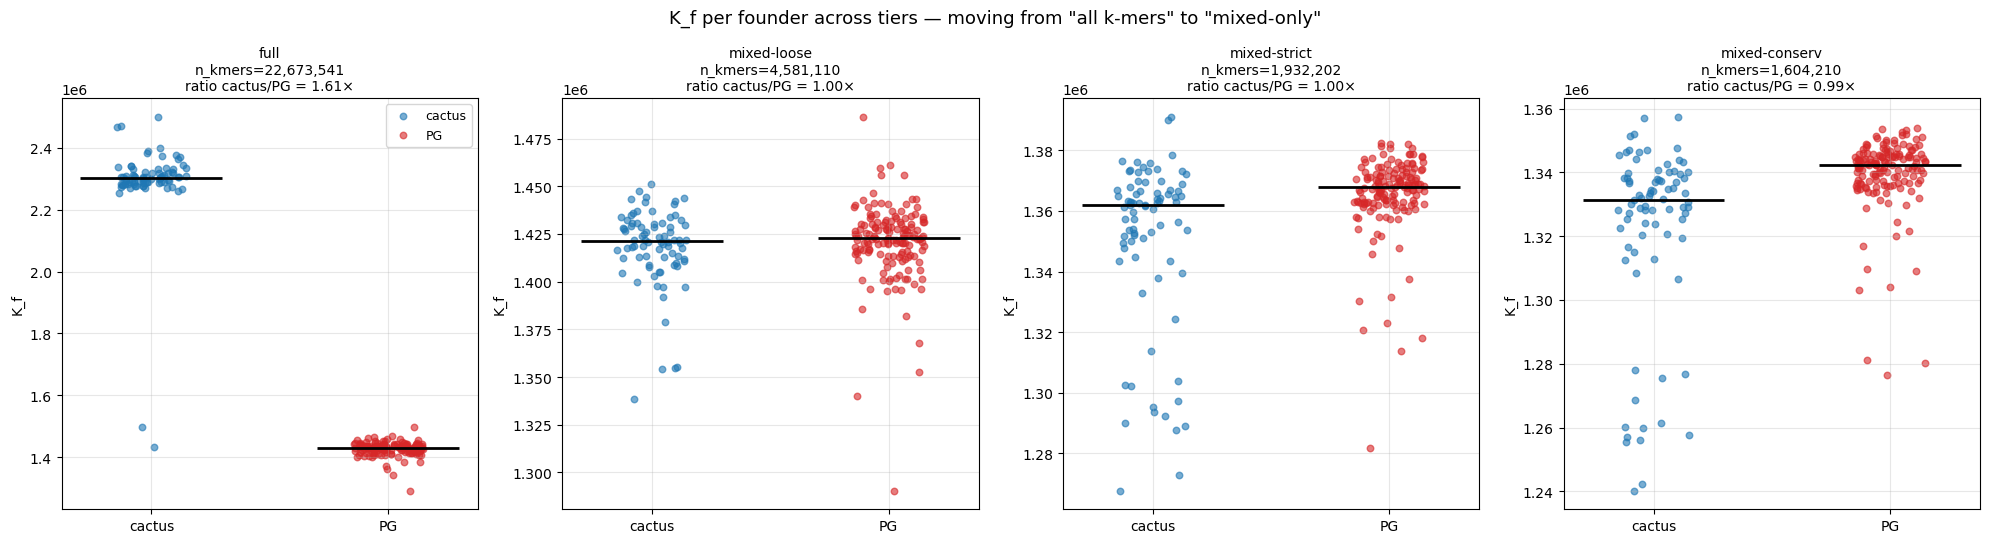

In [10]:
# Plot: per-tier K_f distributions per side (strip plots side-by-side)
fig, axes = plt.subplots(1, 4, figsize=(20, 5.5), sharey=False)
for i, label in enumerate(TIER_LABELS):
    ax = axes[i]
    Kf_t = tier_stats[label]['Kf']
    jc = np.random.uniform(-0.15, 0.15, n_cactus)
    jp = np.random.uniform(-0.15, 0.15, n_pg)
    ax.scatter(jc + 0, Kf_t[is_cactus], color='#1f77b4', alpha=0.6, s=22, label='cactus')
    ax.scatter(jp + 1, Kf_t[is_pg],     color='#d62728', alpha=0.6, s=22, label='PG')
    for x, vals in [(0, Kf_t[is_cactus]), (1, Kf_t[is_pg])]:
        ax.hlines(np.median(vals), x-0.3, x+0.3, colors='k', lw=2)
    med_c = np.median(Kf_t[is_cactus]); med_p = np.median(Kf_t[is_pg])
    ratio = med_c / max(med_p, 1)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['cactus', 'PG'])
    ax.set_ylabel('K_f')
    ax.set_title(f'{label}\nn_kmers={tier_stats[label]["n_kmers"]:,}\nratio cactus/PG = {ratio:.2f}×',
                 fontsize=10)
    ax.grid(alpha=0.3)
    if i == 0:
        ax.legend(fontsize=9)

plt.suptitle('K_f per founder across tiers — moving from "all k-mers" to "mixed-only"',
             fontsize=13)
plt.tight_layout()
plt.savefig('plots/CN_FULL_COMPOSITION_mixedtiers_kf.png', dpi=130, bbox_inches='tight')
plt.show()

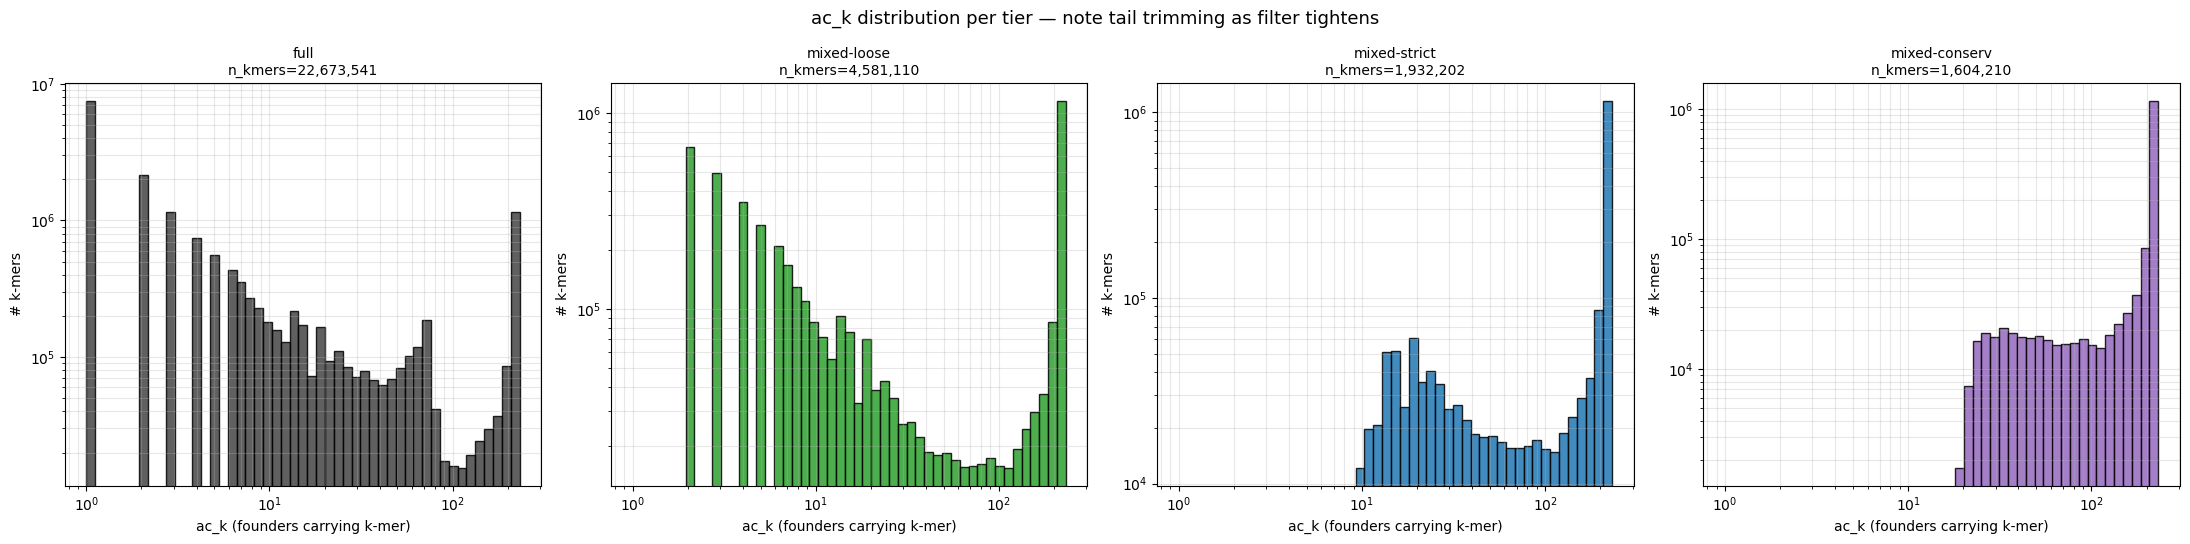

In [11]:
# Plot: per-tier ac_k distributions on the SUBSET
fig, axes = plt.subplots(1, 4, figsize=(22, 5.5), sharey=False)
for i, label in enumerate(TIER_LABELS):
    ax = axes[i]
    m = tier_stats[label]['mask']
    ac_sub = ac[m]
    log_bins = np.logspace(0, np.log10(F + 1), 50)
    ax.hist(ac_sub, bins=log_bins, color=TIER_COLORS[i], edgecolor='k', alpha=0.85)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('ac_k (founders carrying k-mer)')
    ax.set_ylabel('# k-mers')
    ax.set_title(f'{label}\nn_kmers={m.sum():,}', fontsize=10)
    ax.grid(alpha=0.3, which='both')

plt.suptitle('ac_k distribution per tier — note tail trimming as filter tightens', fontsize=13)
plt.tight_layout()
plt.savefig('plots/CN_FULL_COMPOSITION_mixedtiers_ac.png', dpi=130, bbox_inches='tight')
plt.show()

In [12]:
# Summary table: per-tier metrics
import pandas as pd
rows = []
for label in TIER_LABELS:
    Kf_t = tier_stats[label]['Kf']
    priv_t = tier_stats[label]['priv_per_founder']
    rows.append({
        'tier': label,
        'n_kmers': tier_stats[label]['n_kmers'],
        'frac_of_full': f'{tier_stats[label]["n_kmers"]/K*100:.2f}%',
        'Kf_cactus_med': f'{int(np.median(Kf_t[is_cactus])):,}',
        'Kf_PG_med': f'{int(np.median(Kf_t[is_pg])):,}',
        'Kf_ratio_C/PG': f'{np.median(Kf_t[is_cactus])/max(np.median(Kf_t[is_pg]),1):.3f}',
        'priv_cactus_med': f'{int(np.median(priv_t[is_cactus])):,}',
        'priv_PG_med': f'{int(np.median(priv_t[is_pg])):,}',
    })
tier_df = pd.DataFrame(rows)
print(tier_df.to_string(index=False))

         tier  n_kmers frac_of_full Kf_cactus_med Kf_PG_med Kf_ratio_C/PG priv_cactus_med priv_PG_med
         full 22673541      100.00%     2,303,589 1,431,243         1.610          54,345       1,401
  mixed-loose  4581110       20.20%     1,421,351 1,422,764         0.999               0           0
 mixed-strict  1932202        8.52%     1,361,848 1,367,813         0.996               0           0
mixed-conserv  1604210        7.08%     1,331,466 1,342,417         0.992               0           0


In [13]:
tier_df

,tier,n_kmers,frac_of_full,Kf_cactus_med,Kf_PG_med,Kf_ratio_C/PG,priv_cactus_med,priv_PG_med
0,full,22673541,100.00%,"2,303,589","1,431,243",1.610,"54,345","1,401"
1,mixed-loose,4581110,20.20%,"1,421,351","1,422,764",0.999,0,0
2,mixed-strict,1932202,8.52%,"1,361,848","1,367,813",0.996,0,0
3,mixed-conserv,1604210,7.08%,"1,331,466","1,342,417",0.992,0,0
